In [6]:
!pip install nltk
!pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 6.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.2/653.2 kB 4.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.1/741.1 kB 4.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.0 MB/s  0:00:00
  Attempting uninstall: typer╺━━━━━━━━━━━━━━━━━━  9/17 [srsly]
    Found existing installation: typer 0.21.1━━━━━━━━━━━━━━━━━  9/17 [srsly]
    Uninstalling typer-0.21.1:╺━━━━━━━━━━━━━━━━━━  9/17 [srsly]
      Successfully uninstalled typer-0.21.1m━━━━━━━━━━━━━━━━━━  9/17 [srsly]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [spacy]m16/17 [spacy]


In [10]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.6 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/vigne/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [10]:
from util import *

# Add your import statements here
import re
import nltk
import spacy
from nltk.tokenize import sent_tokenize, PunktTokenizer

class SentenceSegmentation():

	def __init__(self):
		# Load spaCy model (students may use this if needed)
		self.nlp = spacy.load("en_core_web_sm")

	def naive(self, text):
		"""
		Sentence Segmentation using a Naive Approach

		Parameters
		----------
		arg1 : str
			A string (a bunch of sentences)

		Returns
		-------
		list
			A list of strings where each string is a single sentence
		"""

		segmentedText = None
		#Our approach here is to have a top-down set of rules to detect patterns that are followed by sentences predominantly
		#I am only considering the following situation - a punctuation followed by a space, that is not a part of a number or a part of an abbreviation, though it may end an abbreviation
		#regex is used for this pattern matching
		pattern = r'(?<=[.!?])\s+(?=[A-Z, 1-9])'
		segmentedText = re.split(pattern, text)
		return segmentedText


	def punkt(self, text):
		"""
		Sentence Segmentation using the Punkt Tokenizer

		Parameters
		----------
		arg1 : str
			A string (a bunch of sentences)

		Returns
		-------
		list
			A list of strings where each string is a single sentence
		"""

		segmentedText = None
		# We now use a pretrained tokenizer, in order to load the trained weights, we do not use PunktTaokenizer, but its wrapper - sent_tokenize
		text = text.strip()
		segmentedText = sent_tokenize(text)
		return segmentedText

	def spacySegmenter(self, text):
		"""
		Sentence Segmentation using spaCy

		Parameters
		----------
		arg1 : str
			A string (a bunch of sentences)

		Returns
		-------
		list
			A list of strings where each string is a single sentence
		"""
		segmentedText = None
		#We use the pretrained sentence segmentation model of spacy, that was trained for general purpose English text found on the web
		segmentedTextCorpus = self.nlp(text)
		#We convert the extracted sentences to a list, and since we require string outputs, we use the .text method
		segmentedText = [sentence.text for sentence in segmentedTextCorpus.sents]
		return segmentedText


In [11]:
obj1 = SentenceSegmentation()
func1 = obj1.spacySegmenter("Grocery list: 1. Apples 2. Bananas 3. Carrots")
print(func1)


['Grocery list: 1.', 'Apples 2.', 'Bananas 3.', 'Carrots']


In [12]:
import nltk

# Ensure you have the punkt tokenizer downloaded
nltk.download('punkt', quiet=True)

# Initialize your class
obj1 = SentenceSegmentation()

# The 15 adversarial sentences and their EXPECTED (correct) segmentations
test_bench = [
    {
        "text": 'Dr. J. R. R. Tolkien, Jr. was an author.',
        "expected": ['Dr. J. R. R. Tolkien, Jr. was an author.']
    },
    {
        "text": 'He yelled, "Stop right there!" Then he ran.',
        "expected": ['He yelled, "Stop right there!"', 'Then he ran.']
    },
    {
        "text": 'i went to the store. they were out of milk. so i left.',
        "expected": ['i went to the store.', 'they were out of milk.', 'so i left.']
    },
    {
        "text": "Let's meet on Oct. 14. 2026 is going to be a great year.",
        "expected": ["Let's meet on Oct. 14.", "2026 is going to be a great year."]
    },
    {
        "text": 'Grocery list: 1. Apples. 2. Bananas. 3. Carrots.',
        "expected": ['Grocery list: 1. Apples.', '2. Bananas.', '3. Carrots.']
    },
    {
        "text": 'The item costs Rs. 50. 20 is the maximum discount.',
        "expected": ['The item costs Rs. 50.', '20 is the maximum discount.']
    },
    {
        "text": 'while (x < 5.) { x++; }. That is the loop.',
        "expected": ['while (x < 5.) { x++; }.', 'That is the loop.']
    },
    {
        "text": 'Have you read "Do Androids Dream of Electric Sheep?" Today, it is considered a classic.',
        "expected": ['Have you read "Do Androids Dream of Electric Sheep?"', 'Today, it is considered a classic.']
    },
    {
        "text": 'I am so happy today!!! ... :-) Are you coming?',
        "expected": ['I am so happy today!!! ... :-)', 'Are you coming?']
    },
    {
        "text": 'Prof. A. B. Smith (b. 1920) lived in Washington, D.C. His entire life.',
        "expected": ['Prof. A. B. Smith (b. 1920) lived in Washington, D.C. His entire life.']
    },
    {
        "text": 'She whispered... "Who is there?"',
        "expected": ['She whispered... "Who is there?"']
    },
    {
        "text": 'Wait, what?! Why are we doing this?!',
        "expected": ['Wait, what?!', 'Why are we doing this?!']
    },
    {
        "text": 'Just sitting here. In the dark. Alone.',
        "expected": ['Just sitting here.', 'In the dark.', 'Alone.']
    },
    {
        "text": 'I bought apples, oranges, etc. They were very fresh.',
        "expected": ['I bought apples, oranges, etc.', 'They were very fresh.']
    },
    {
        "text": 'And then I was like omg and he was like no way and I ran out.',
        "expected": ['And then I was like omg and he was like no way and I ran out.']
    }
]

# Helper function to clean the outputs for a fair comparison
def clean_output(sentence_list):
    if not sentence_list:
        return []
    # Strip whitespace and remove empty strings
    return [s.strip() for s in sentence_list if s.strip()]

# Run the evaluation
print("=== ADVERSARIAL TEST SUITE EVALUATION ===\n")

for i, test in enumerate(test_bench, 1):
    text = test["text"]
    expected = test["expected"]
    
    print(f"--- Test Case {i} ---")
    print(f"TEXT: {text}")
    
    # Get predictions (Make sure your naive and punkt methods are implemented!)
    out_naive = clean_output(obj1.naive(text))
    out_punkt = clean_output(obj1.punkt(text))
    out_spacy = clean_output(obj1.spacySegmenter(text))
    
    # Track if anyone got it wrong
    errors_found = False
    
    if out_naive != expected:
        print(f"❌ NAIVE failed.")
        print(f"   Expected: {expected}")
        print(f"   Got:      {out_naive}")
        errors_found = True
        
    if out_punkt != expected:
        print(f"❌ PUNKT failed.")
        print(f"   Expected: {expected}")
        print(f"   Got:      {out_punkt}")
        errors_found = True
        
    if out_spacy != expected:
        print(f"❌ SPACY failed.")
        print(f"   Expected: {expected}")
        print(f"   Got:      {out_spacy}")
        errors_found = True
        
    if not errors_found:
        print("✅ All segmenters got this right! (Wait, you might need a harder sentence!)")
        
    print("\n" + "="*50 + "\n")

=== ADVERSARIAL TEST SUITE EVALUATION ===

--- Test Case 1 ---
TEXT: Dr. J. R. R. Tolkien, Jr. was an author.
❌ NAIVE failed.
   Expected: ['Dr. J. R. R. Tolkien, Jr. was an author.']
   Got:      ['Dr.', 'J.', 'R.', 'R.', 'Tolkien, Jr. was an author.']


--- Test Case 2 ---
TEXT: He yelled, "Stop right there!" Then he ran.
❌ NAIVE failed.
   Expected: ['He yelled, "Stop right there!"', 'Then he ran.']
   Got:      ['He yelled, "Stop right there!" Then he ran.']


--- Test Case 3 ---
TEXT: i went to the store. they were out of milk. so i left.
❌ NAIVE failed.
   Expected: ['i went to the store.', 'they were out of milk.', 'so i left.']
   Got:      ['i went to the store. they were out of milk. so i left.']


--- Test Case 4 ---
TEXT: Let's meet on Oct. 14. 2026 is going to be a great year.
❌ NAIVE failed.
   Expected: ["Let's meet on Oct. 14.", '2026 is going to be a great year.']
   Got:      ["Let's meet on Oct.", '14.', '2026 is going to be a great year.']


--- Test Case 5 ---
TEXT

In [27]:
from util import *

# Add your import statements here
# (Students may import required libraries such as nltk, spacy, re, etc.)
import re
import nltk
import spacy
from nltk.tokenize import TreebankWordTokenizer

class Tokenization():

	def __init__(self):
        #Load spaCy model for the spaCy tokenizer
		self.nlp = spacy.load("en_core_web_sm")
        #Initialize the Penn Treebank Tokenizer
		self.ptb_tokenizer = TreebankWordTokenizer()

	def naive(self, text):
		"""
		Tokenization using a Naive Approach

		Parameters
		----------
		arg1 : list
			A list of strings where each string is a single sentence

		Returns
		-------
		list
			A list of lists where each sub-list is a sequence of tokens
		"""

		tokenizedText = []
		#Append every string of alphanumeric characters as a word to the list of tokens, and stop for every whitespace character. 
		#If a non-whitespace non-alphanumeric chacrater is found, then it is separately tokenized
		pattern = r'\w+|[^\w\s]'
		for sentence in text:
			tokens = re.findall(pattern, sentence)
			tokenizedText.append(tokens)
		return tokenizedText


	def pennTreeBank(self, text):
		"""
		Tokenization using the Penn Tree Bank Tokenizer

		Parameters
		----------
		arg1 : list
			A list of strings where each string is a single sentence

		Returns
		-------
		list
			A list of lists where each sub-list is a sequence of tokens
		"""

		tokenizedText = []
        # This tokenizer handles clitics and punctuation intelligently based on PTB rules
		for sentence in text:
			tokens = self.ptb_tokenizer.tokenize(sentence)
			tokenizedText.append(tokens)
		return tokenizedText

	def spacyTokenizer(self, text):
		"""
		Tokenization using spaCy

		Parameters
		----------
		arg1 : list
			A list of strings where each string is a single sentence

		Returns
		-------
		list
			A list of lists where each sub-list is a sequence of tokens
		"""

		tokenizedText = []
        # spaCy uses a hybrid approach (whitespace splitting + exception dictionaries + affix rules)
		for sentence in text:
			doc = self.nlp(sentence)
            # Extract the string representation (.text) of each token
			tokens = [token.text for token in doc]
			tokenizedText.append(tokens)
		return tokenizedText


In [28]:
# Initialize your tokenizer class
tokenizer_obj = Tokenization()

# Your 15 adversarial sentences
test_sentences = [
    'Dr. J. R. R. Tolkien, Jr. was an author.',
    'He yelled, "Stop right there!" Then he ran.',
    'i went to the store. they were out of milk. so i left.',
    "Let's meet on Oct. 14. 2026 is going to be a great year.",
    'Grocery list: 1. Apples. 2. Bananas. 3. Carrots.',
    'The item costs Rs. 50. 20 is the maximum discount.',
    'while (x < 5.) { x++; }. That is the loop.',
    'Have you read "Do Androids Dream of Electric Sheep?" Today, it is considered a classic.',
    'I am so happy today!!! ... :-) Are you coming?',
    'Prof. A. B. Smith (b. 1920) lived in Washington, D.C. His entire life.',
    'She whispered... "Who is there?"',
    'Wait, what?! Why are we doing this?!',
    'Just sitting here. In the dark. Alone.',
    'I bought apples, oranges, etc. They were very fresh.',
    'And then I was like omg and he was like no way and I ran out.'
]

print("=== TOKENIZATION EVALUATION ===\n")

for i, text in enumerate(test_sentences, 1):
    print(f"--- Sentence {i} ---")
    print(f"TEXT:  {text}")
    
    # We pass [text] as a list because your methods expect a list of sentences
    out_naive = tokenizer_obj.naive([text])[0]
    out_ptb = tokenizer_obj.pennTreeBank([text])[0]
    out_spacy = tokenizer_obj.spacyTokenizer([text])[0]
    
    print(f"NAIVE: {out_naive}")
    print(f"PTB:   {out_ptb}")
    print(f"SPACY: {out_spacy}")
    print("="*60 + "\n")

=== TOKENIZATION EVALUATION ===

--- Sentence 1 ---
TEXT:  Dr. J. R. R. Tolkien, Jr. was an author.
NAIVE: ['Dr', '.', 'J', '.', 'R', '.', 'R', '.', 'Tolkien', ',', 'Jr', '.', 'was', 'an', 'author', '.']
PTB:   ['Dr.', 'J.', 'R.', 'R.', 'Tolkien', ',', 'Jr.', 'was', 'an', 'author', '.']
SPACY: ['Dr.', 'J.', 'R.', 'R.', 'Tolkien', ',', 'Jr.', 'was', 'an', 'author', '.']

--- Sentence 2 ---
TEXT:  He yelled, "Stop right there!" Then he ran.
NAIVE: ['He', 'yelled', ',', '"', 'Stop', 'right', 'there', '!', '"', 'Then', 'he', 'ran', '.']
PTB:   ['He', 'yelled', ',', '``', 'Stop', 'right', 'there', '!', "''", 'Then', 'he', 'ran', '.']
SPACY: ['He', 'yelled', ',', '"', 'Stop', 'right', 'there', '!', '"', 'Then', 'he', 'ran', '.']

--- Sentence 3 ---
TEXT:  i went to the store. they were out of milk. so i left.
NAIVE: ['i', 'went', 'to', 'the', 'store', '.', 'they', 'were', 'out', 'of', 'milk', '.', 'so', 'i', 'left', '.']
PTB:   ['i', 'went', 'to', 'the', 'store.', 'they', 'were', 'out', 'of'

In [33]:
text = """3 + 5 = 7"""
out_naive = tokenizer_obj.naive([text])[0]
out_ptb = tokenizer_obj.pennTreeBank([text])[0]
out_spacy = tokenizer_obj.spacyTokenizer([text])[0]

print(f"NAIVE: {out_naive}")
print(f"PTB:   {out_ptb}")
print(f"SPACY: {out_spacy}")

NAIVE: ['3', '+', '5', '=', '7']
PTB:   ['3', '+', '5', '=', '7']
SPACY: ['3', '+', '5', '=', '7']


In [41]:
from util import *

# Add your import statements here
# (Students may import required libraries such as nltk, WordNetLemmatizer, PorterStemmer, etc.)
import nltk
from nltk import pos_tag
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

class InflectionReduction:

	def __init__(self):
        # Initialize the tools once to save computational overhead
		self.stemmer = PorterStemmer()
		self.lemmatizer = WordNetLemmatizer()

	def get_wordnet_pos(self, tag):
		"""
		Helper method to map NLTK's Treebank POS tags to WordNet POS tags.
		"""
		if tag.startswith('J'):
			return 'a' #Adjective
		elif tag.startswith('V'):
			return 'v' #Verb
		elif tag.startswith('N'):
			return 'n' #Noun
		elif tag.startswith('R'):
			return 'r' #Adverb
		else:
			return 'n' #Default to noun

	def porterStemmer(self, text):
		"""
		Inflection Reduction using Porter Stemmer

		Parameters
		----------
		arg1 : list
			A list of lists where each sub-list is a sequence of tokens
			representing a sentence

		Returns
		-------
		list
			A list of lists where each sub-list is a sequence of
			stemmed tokens representing a sentence
		"""

		reducedText = []
		for sentence in text:
            #Apply the stemmer to each token in the sentence
			stemmed_sentence = [self.stemmer.stem(token) for token in sentence]
			reducedText.append(stemmed_sentence)
		return reducedText



	def wordnetLemmatizer(self, text):
		"""
		Inflection Reduction using WordNet Lemmatizer

		Parameters
		----------
		arg1 : list
			A list of lists where each sub-list is a sequence of tokens
			representing a sentence

		Returns
		-------
		list
			A list of lists where each sub-list is a sequence of
			lemmatized tokens representing a sentence
		"""

		reducedText = []
		for sentence in text:
            #Apply the lemmatizer to each token. 
            #Without explicit POS tags passed in, WordNetLemmatizer defaults to treating words as nouns. 
			#So to improve the quality of the lemmatization, we also use pos tagging
			lemmatized_sentence = []
			tagged_tokens = pos_tag(sentence)
			for word, tag in tagged_tokens:
				wn_tag = self.get_wordnet_pos(tag)
				lemmatized_sentence.append(self.lemmatizer.lemmatize(word, wn_tag))
			reducedText.append(lemmatized_sentence)
		return reducedText


	def reduce(self, text):
		"""
		Wrapper function for inflection reduction.
		Students may choose which method to call
		or extend this function to support both options.
		"""

		reducedText = None
		#Use the lemmatizer as the standard default function
		reducedText = self.wordnetLemmatizer(text)
		return reducedText


In [44]:
# Initialize your InflectionReduction class
reducer = InflectionReduction()

# Define test sentences (pre-tokenized as expected by your methods)
test_sentences = [
    ["The", "children", "are", "running", "towards", "a", "better", "place", "."],
    ["He", "studies", "hard", "because", "he", "cares", "about", "his", "future", "."],
    ["The", "leaves", "on", "the", "trees", "are", "falling", "rapidly", "."],
    ["She", "organizes", "various", "organizations", "systematically", "."]
]

print("=== INFLECTION REDUCTION EVALUATION ===\n")

# Get outputs
stemmed_output = reducer.porterStemmer(test_sentences)
lemmatized_output = reducer.wordnetLemmatizer(test_sentences)

# Track vocabulary sizes
original_vocab = set()
stemmed_vocab = set()
lemmatized_vocab = set()

for i in range(len(test_sentences)):
    print(f"--- Sentence {i+1} ---")
    print(f"ORIGINAL:   {test_sentences[i]}")
    print(f"STEMMED:    {stemmed_output[i]}")
    print(f"LEMMATIZED: {lemmatized_output[i]}")
    print("-" * 50)
    
    # Add to vocab sets to calculate size later
    original_vocab.update([word.lower() for word in test_sentences[i]])
    stemmed_vocab.update([word.lower() for word in stemmed_output[i]])
    lemmatized_vocab.update([word.lower() for word in lemmatized_output[i]])

print("\n=== VOCABULARY SIZE ANALYSIS ===")
print(f"Original Vocabulary Size:   {len(original_vocab)}")
print(f"Stemmed Vocabulary Size:    {len(stemmed_vocab)}")
print(f"Lemmatized Vocabulary Size: {len(lemmatized_vocab)}")

=== INFLECTION REDUCTION EVALUATION ===

--- Sentence 1 ---
ORIGINAL:   ['The', 'children', 'are', 'running', 'towards', 'a', 'better', 'place', '.']
STEMMED:    ['the', 'children', 'are', 'run', 'toward', 'a', 'better', 'place', '.']
LEMMATIZED: ['The', 'child', 'be', 'run', 'towards', 'a', 'good', 'place', '.']
--------------------------------------------------
--- Sentence 2 ---
ORIGINAL:   ['He', 'studies', 'hard', 'because', 'he', 'cares', 'about', 'his', 'future', '.']
STEMMED:    ['he', 'studi', 'hard', 'becaus', 'he', 'care', 'about', 'hi', 'futur', '.']
LEMMATIZED: ['He', 'study', 'hard', 'because', 'he', 'care', 'about', 'his', 'future', '.']
--------------------------------------------------
--- Sentence 3 ---
ORIGINAL:   ['The', 'leaves', 'on', 'the', 'trees', 'are', 'falling', 'rapidly', '.']
STEMMED:    ['the', 'leav', 'on', 'the', 'tree', 'are', 'fall', 'rapidli', '.']
LEMMATIZED: ['The', 'leaf', 'on', 'the', 'tree', 'be', 'fall', 'rapidly', '.']
------------------------

In [ ]:
from sentenceSegmentation import SentenceSegmentation
from tokenization import Tokenization
from inflectionReduction import InflectionReduction
from stopwordRemoval import StopwordRemoval

import argparse
import json
import os
from sys import version_info
import nltk

# Input compatibility for Python 2 and Python 3
if version_info.major == 3:
    pass
elif version_info.major == 2:
    try:
        input = raw_input
    except NameError:
        pass
else:
    print("Unknown python version - input function not safe")


class SearchEngine:

    def __init__(self, args):
        self.args = args
        self.tokenizer = Tokenization()
        self.sentenceSegmenter = SentenceSegmentation()
        self.inflectionReducer = InflectionReduction()
        self.stopwordRemover = StopwordRemoval()

        # Create output folder if not exists
        if not os.path.exists(self.args.out_folder):
            os.makedirs(self.args.out_folder)

    def segmentSentences(self, text):
        if self.args.segmenter == "naive":
            return self.sentenceSegmenter.naive(text)
        elif self.args.segmenter == "punkt":
            return self.sentenceSegmenter.punkt(text)
        elif self.args.segmenter == "spacy":
            return self.sentenceSegmenter.spacySegmenter(text)

    def tokenize(self, text):
        if self.args.tokenizer == "naive":
            return self.tokenizer.naive(text)
        elif self.args.tokenizer == "ptb":
            return self.tokenizer.pennTreeBank(text)
        elif self.args.tokenizer == "spacy":
            return self.tokenizer.spacyTokenizer(text)

    def reduceInflection(self, text):
        return self.inflectionReducer.reduce(text)

    def removeStopwords(self, text):
        return self.stopwordRemover.fromList(text)


    def preprocessQueries(self, queries):

        segmentedQueries = []
        for query in queries:
            segmentedQueries.append(self.segmentSentences(query))

        with open(os.path.join(self.args.out_folder, "segmented_queries.txt"), 'w') as f:
            json.dump(segmentedQueries, f)

        tokenizedQueries = []
        for query in segmentedQueries:
            tokenizedQueries.append(self.tokenize(query))

        with open(os.path.join(self.args.out_folder, "tokenized_queries.txt"), 'w') as f:
            json.dump(tokenizedQueries, f)

        reducedQueries = []
        for query in tokenizedQueries:
            reducedQueries.append(self.reduceInflection(query))

        with open(os.path.join(self.args.out_folder, "reduced_queries.txt"), 'w') as f:
            json.dump(reducedQueries, f)

        stopwordRemovedQueries = []
        for query in reducedQueries:
            stopwordRemovedQueries.append(self.removeStopwords(query))

        with open(os.path.join(self.args.out_folder, "stopword_removed_queries.txt"), 'w') as f:
            json.dump(stopwordRemovedQueries, f)

        return stopwordRemovedQueries


    def preprocessDocs(self, docs):

        segmentedDocs = []
        for doc in docs:
            segmentedDocs.append(self.segmentSentences(doc))

        with open(os.path.join(self.args.out_folder, "segmented_docs.txt"), 'w') as f:
            json.dump(segmentedDocs, f)

        tokenizedDocs = []
        for doc in segmentedDocs:
            tokenizedDocs.append(self.tokenize(doc))

        with open(os.path.join(self.args.out_folder, "tokenized_docs.txt"), 'w') as f:
            json.dump(tokenizedDocs, f)

        reducedDocs = []
        for doc in tokenizedDocs:
            reducedDocs.append(self.reduceInflection(doc))

        with open(os.path.join(self.args.out_folder, "reduced_docs.txt"), 'w') as f:
            json.dump(reducedDocs, f)

        stopwordRemovedDocs = []
        for doc in reducedDocs:
            stopwordRemovedDocs.append(self.removeStopwords(doc))

        with open(os.path.join(self.args.out_folder, "stopword_removed_docs.txt"), 'w') as f:
            json.dump(stopwordRemovedDocs, f)

        return stopwordRemovedDocs


    def evaluateDataset(self):

        query_path = os.path.join(self.args.dataset, "cran_queries.json")
        doc_path = os.path.join(self.args.dataset, "cran_docs.json")

        with open(query_path, 'r') as f:
            queries_json = json.load(f)

        queries = [item["query"] for item in queries_json]
        self.preprocessQueries(queries)

        with open(doc_path, 'r') as f:
            docs_json = json.load(f)

        docs = [item["body"] for item in docs_json]
        self.preprocessDocs(docs)


    def handleCustomQuery(self):

        print("Enter query below")
        query = input()

        self.preprocessQueries([query])

        doc_path = os.path.join(self.args.dataset, "cran_docs.json")

        with open(doc_path, 'r') as f:
            docs_json = json.load(f)

        docs = [item["body"] for item in docs_json]
        self.preprocessDocs(docs)


if __name__ == "__main__":

    parser = argparse.ArgumentParser(description='main.py')

    parser.add_argument('-dataset', default="cranfield",
                        help="Path to dataset folder")
    parser.add_argument('-out_folder', default="output",
                        help="Path to output folder")
    parser.add_argument('-segmenter', default="punkt",
                        help="Sentence Segmenter Type [naive|punkt|spacy]")
    parser.add_argument('-tokenizer', default="ptb",
                        help="Tokenizer Type [naive|ptb|spacy]")
    parser.add_argument('-custom', action="store_true",
                        help="Take custom query as input")

    args = parser.parse_args()

    searchEngine = SearchEngine(args)

    if args.custom:
        searchEngine.handleCustomQuery()
    else:
        searchEngine.evaluateDataset()

usage: ipykernel_launcher.py [-h] [-dataset DATASET] [-out_folder OUT_FOLDER]
                             [-segmenter SEGMENTER] [-tokenizer TOKENIZER]
                             [-custom]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/vigne/Library/Jupyter/runtime/kernel-v3704207e3c846cd607d8c18321ed65dff869efa68.json


SystemExit: 2

/Users/vigne/miniforge3/envs/general/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [48]:
import nltk
from nltk.corpus import stopwords

# Ensure it's downloaded
nltk.download('stopwords', quiet=True)

nltk_list = stopwords.words('english')
print(f"Total NLTK Stopwords: {len(nltk_list)}")
print(nltk_list)

Total NLTK Stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'sam

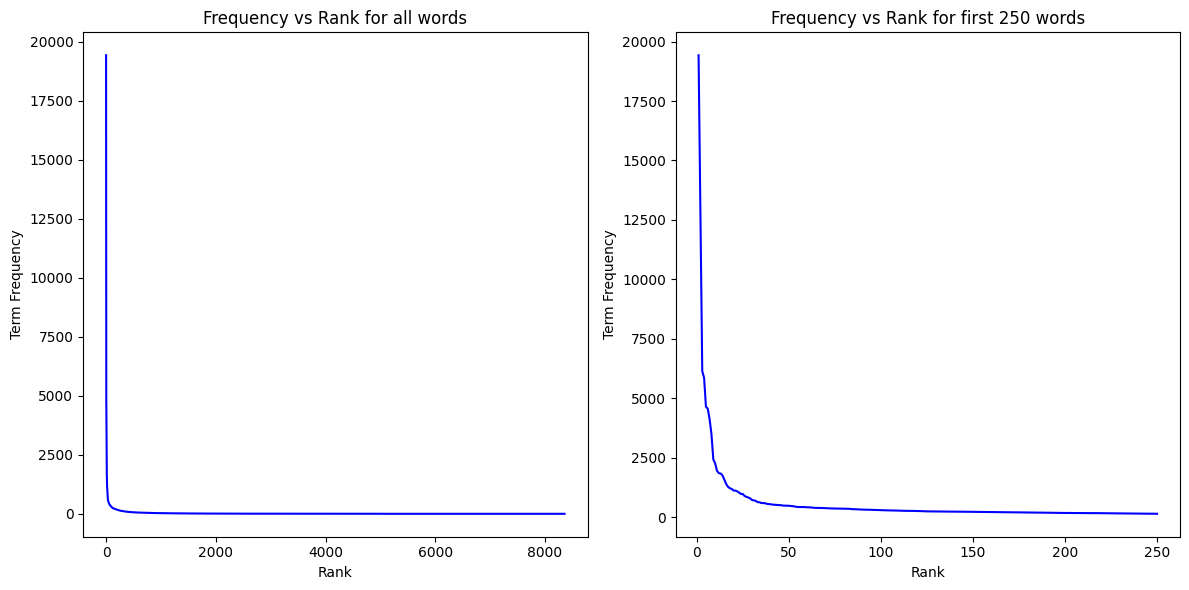


=== STOPWORD COMPARISON RESULTS ===
Number of NLTK Stopwords: 198
Number of Custom (Zipf) Stopwords identified: 168

Overlap between the two lists: 45 words
Examples of overlap: ['such', 'about', 'or', 'has', 'to', 'at', 'it', 'over', 'a', 'when']

Words in NLTK but NOT in Custom List: 153 words
Examples: ["it'll", "that'll", 'should', "you'll", "mightn't", 'needn', 'his', "needn't", "she'll", 'ourselves']

Words in Custom List but NOT in NLTK (Domain Specific): 123 words
Examples: ['fluid', 'flight', 'point', 'measurements', 'approximate', 'based', 'general', 'equations', 'high', 'region']


In [77]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords

# 1. Load NLTK Stopwords
nltk.download('stopwords', quiet=True)
nltk_stopwords = set(stopwords.words('english'))

# 2. Load your preprocessed Cranfield documents
# Make sure the path points to where your main.py saved the file!
try:
    with open('output/tokenized_docs.txt', 'r') as f:
        reduced_docs = json.load(f)
except FileNotFoundError:
    print("Error: Could not find 'output/tokenized_docs.txt'. Run main.py first!")
    exit()

# 3. Flatten the nested list structure to get a single list of all tokens
all_tokens = []
for doc in reduced_docs:
    for sentence in doc:
        for token in sentence:
            # We filter out raw punctuation strings that might have slipped through
            if token.strip() and token not in ['.', ',', '!', '?', '(', ')', '-', '/']:
                all_tokens.append(token.lower())

# 4. Generate Term Frequencies and Rank them (Zipf's Law)
word_counts = Counter(all_tokens)
sorted_counts = word_counts.most_common() # Sorts descending automatically

frequencies = [count for word, count in sorted_counts]
words = [word for word, count in sorted_counts]
ranks = list(range(1, len(frequencies) + 1))

# 5. Plot the Graph (Term Frequencies vs. Ranks)
plt.figure(figsize=(12, 6))

# Standard Plot
plt.subplot(1, 2, 1)
plt.plot(ranks, frequencies, color='blue')
plt.title("Frequency vs Rank for all words")
plt.xlabel("Rank")
plt.ylabel("Term Frequency")

# Log-Log Plot (Zipf's Law is best visualized on a logarithmic scale)
plt.subplot(1, 2, 2)
plt.plot(ranks[:250], frequencies[:250], color='blue')
plt.title("Frequency vs Rank for first 250 words")
plt.xlabel("Rank")
plt.ylabel("Term Frequency")

plt.tight_layout()
plt.show()

# 6. Choose a threshold
# Looking at typical Cranfield distributions, words appearing more than ~200 times 
# or the top ~50 ranked words are usually structural noise.
# Let's set a frequency threshold (you can change this based on your graph!)


FREQUENCY_THRESHOLD = 198.08 

custom_stopwords = set()
for word, count in sorted_counts:
    if count >= FREQUENCY_THRESHOLD:
        custom_stopwords.add(word)

# 7. Evaluate and Compare with NLTK
print("\n=== STOPWORD COMPARISON RESULTS ===")
print(f"Number of NLTK Stopwords: {len(nltk_stopwords)}")
print(f"Number of Custom (Zipf) Stopwords identified: {len(custom_stopwords)}\n")

overlap = nltk_stopwords.intersection(custom_stopwords)
print(f"Overlap between the two lists: {len(overlap)} words")
print(f"Examples of overlap: {list(overlap)[:10]}\n")

only_in_nltk = nltk_stopwords.difference(custom_stopwords)
print(f"Words in NLTK but NOT in Custom List: {len(only_in_nltk)} words")
print(f"Examples: {list(only_in_nltk)[:10]}\n")

only_in_custom = custom_stopwords.difference(nltk_stopwords)
print(f"Words in Custom List but NOT in NLTK (Domain Specific): {len(only_in_custom)} words")
print(f"Examples: {list(only_in_custom)[:10]}")

In [73]:
print(overlap)

{'such', 'about', 'or', 'has', 'to', 'at', 'it', 'over', 'a', 'when', 'not', 'which', 'of', 'as', 'these', 'are', 'some', 'where', 'been', 'all', 'an', 'both', 'into', 'were', 'but', 'other', 'is', 'under', 'have', 'this', 'for', 'in', 'can', 'was', 'the', 'by', 'between', 'from', 'than', 'with', 'on', 'that', 'and', 'only', 'be'}


In [74]:
print(only_in_nltk)

{"it'll", "that'll", 'should', "you'll", "mightn't", 'needn', 'his', "needn't", "she'll", 'ourselves', 'wasn', 've', "haven't", "couldn't", "shan't", "they'd", 'why', 'having', "we've", 'weren', 'through', 'your', "aren't", "i've", 'did', "isn't", 't', 'myself', "they're", 'had', 'above', 'do', 'once', 'she', "it'd", 'same', 'am', 'herself', "should've", 'whom', "she's", "he'll", 'now', "hasn't", "mustn't", "we'd", 'm', "didn't", 'its', 'will', 'so', 'haven', 'me', "he'd", 'nor', "we're", 'y', "hadn't", 'out', "you're", 'our', 'yourselves', 'does', 'up', 'i', 'each', 'you', 'doesn', 'own', 'hadn', "won't", 'during', 'mustn', 'her', 'because', 's', "don't", 'we', 'him', 'no', 'very', 'won', 'ma', 'while', 'shan', 'most', 'being', 'them', 'he', 're', "we'll", 'until', 'aren', 'ain', 'itself', 'further', "she'd", "i'd", 'if', "wouldn't", "you'd", 'mightn', 'what', 'here', 'against', 'yours', 'couldn', 'just', 'themselves', 'wouldn', 'hasn', 'those', "weren't", 'd', "you've", 'himself', 'd

In [75]:
print(only_in_custom)

{'fluid', 'flight', 'point', 'measurements', 'approximate', 'based', 'general', 'equations', 'high', 'region', 'constant', 'theoretical', 'numbers', 'transition', 'dimensional', 'numerical', 'investigation', 'layer', 'made', 'cylinder', 'shock', 'body', '1', 'heat', 'laminar', 'tunnel', "'s", 'also', 'data', 'experimental', 'values', 'results', 'first', 'order', 'mach', 'analysis', 'model', 'found', 'flat', 'lift', 'wings', 'transfer', 'wave', 'low', 'value', 'considered', 'case', 'small', 'temperature', 'velocity', 'use', 'thin', 'methods', 'flutter', 'stress', 'gas', 'leading', 'tests', 'problems', 'may', 'surface', 'flows', 'compared', 'shown', 'buckling', 'one', 'form', 'ratio', 'paper', 'jet', 'hypersonic', 'large', 'agreement', 'field', 'boundary', 'thickness', 'used', 'stagnation', 'effect', 'separation', 'plate', 'aerodynamic', 'effects', 'flow', 'method', 'speeds', 'wing', 'range', 'number', 'distribution', 'stability', 'angle', 'stream', 'presented', 'speed', 'characteristics

In [68]:
import numpy as np
df_counts = Counter()

# We count how many unique documents each word appears in
for doc in reduced_docs:
    unique_words_in_doc = set()
    for sentence in doc:
        for token in sentence:
            if token.strip() and token not in ['.', ',', '!', '?', '(', ')', '-', '/']:
                unique_words_in_doc.add(token.lower())
    
    # Add 1 to the word's DF for this document
    for word in unique_words_in_doc:
        df_counts[word] += 1

# Extract the frequencies to do statistics
df_values = list(df_counts.values())

# 5. Calculate Statistical Significance Threshold (Z-Score approach)
mean_df = np.mean(df_values)
std_df = np.std(df_values)

STATISTICAL_THRESHOLD = mean_df + (2 * std_df)

print(f"Mean Document Frequency: {mean_df:.2f}")
print(f"Standard Deviation: {std_df:.2f}")
print(f"Optimal Statistical Threshold (Mean + 3 StdDev): {STATISTICAL_THRESHOLD:.2f}")

Mean Document Frequency: 14.71
Standard Deviation: 61.12
Optimal Statistical Threshold (Mean + 3 StdDev): 136.95


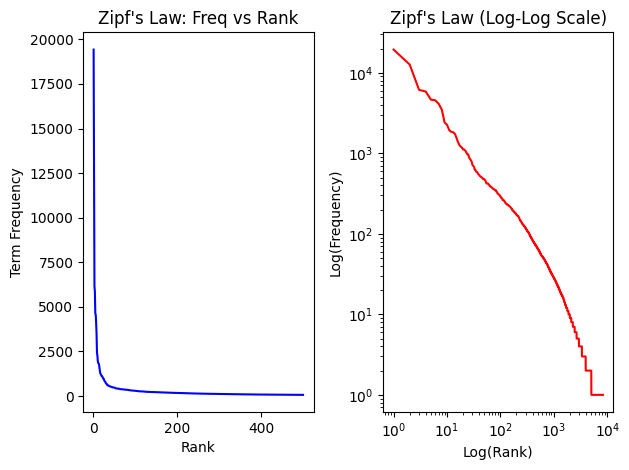


=== STOPWORD COMPARISON RESULTS ===
Number of NLTK Stopwords: 198
Number of Custom (Zipf) Stopwords identified: 45

Overlap between the two lists: 25 words
Examples of overlap: ['to', 'at', 'it', 'a', 'which', 'of', 'these', 'as', 'are', 'an']

Words in NLTK but NOT in Custom List: 173 words
Examples: ["it'll", 'such', "that'll", 'has', 'should', "you'll", "mightn't", 'not', 'his', 'needn']

Words in Custom List but NOT in NLTK (Domain Specific): 20 words
Examples: ['wing', 'number', 'surface', 'results', 'obtained', 'mach', 'pressure', 'two', 'boundary', 'theory']


In [55]:
# Standard Plot
plt.subplot(1, 2, 1)
plt.plot(ranks[:500], frequencies[:500], color='blue')
plt.title("Zipf's Law: Freq vs Rank")
plt.xlabel("Rank")
plt.ylabel("Term Frequency")

# Log-Log Plot (Zipf's Law is best visualized on a logarithmic scale)
plt.subplot(1, 2, 2)
plt.loglog(ranks, frequencies, color='red')
plt.title("Zipf's Law (Log-Log Scale)")
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")

plt.tight_layout()
plt.show()

# 6. Choose a threshold
# Looking at typical Cranfield distributions, words appearing more than ~200 times 
# or the top ~50 ranked words are usually structural noise.
# Let's set a frequency threshold (you can change this based on your graph!)
FREQUENCY_THRESHOLD = 500 

custom_stopwords = set()
for word, count in sorted_counts:
    if count >= FREQUENCY_THRESHOLD:
        custom_stopwords.add(word)

# 7. Evaluate and Compare with NLTK
print("\n=== STOPWORD COMPARISON RESULTS ===")
print(f"Number of NLTK Stopwords: {len(nltk_stopwords)}")
print(f"Number of Custom (Zipf) Stopwords identified: {len(custom_stopwords)}\n")

overlap = nltk_stopwords.intersection(custom_stopwords)
print(f"Overlap between the two lists: {len(overlap)} words")
print(f"Examples of overlap: {list(overlap)[:10]}\n")

only_in_nltk = nltk_stopwords.difference(custom_stopwords)
print(f"Words in NLTK but NOT in Custom List: {len(only_in_nltk)} words")
print(f"Examples: {list(only_in_nltk)[:10]}\n")

only_in_custom = custom_stopwords.difference(nltk_stopwords)
print(f"Words in Custom List but NOT in NLTK (Domain Specific): {len(only_in_custom)} words")
print(f"Examples: {list(only_in_custom)[:10]}")

In [51]:
print(nltk_stopwords)

{"it'll", 'such', "that'll", 'has', 'at', 'it', 'should', "you'll", "mightn't", 'not', 'of', 'his', 'needn', "needn't", "she'll", 'ourselves', 'wasn', 've', 'where', "haven't", "couldn't", "shan't", "they'd", 'under', 'why', 'have', 'having', 'for', "we've", 'weren', 'through', 'your', "aren't", "i've", 'did', "isn't", 't', 'between', 'myself', "they're", 'had', 'above', 'do', 'once', 'she', "it'd", 'same', 'with', 'on', 'am', 'herself', "should've", 'whom', 'be', "she's", "he'll", 'now', 'to', "hasn't", "mustn't", "we'd", 'm', 'a', "didn't", 'its', 'will', 'so', 'haven', 'are', 'me', "he'd", 'nor', "we're", 'y', "hadn't", 'out', "you're", 'our', 'yourselves', 'does', 'up', 'into', 'i', 'each', 'you', 'this', 'doesn', 'own', 'hadn', "won't", 'during', 'mustn', 'by', 'because', 'her', 'from', "don't", 's', 'we', 'him', 'no', 'very', 'won', 'and', 'ma', 'while', 'only', 'shan', 'most', 'being', 'about', 'them', 'he', 're', "we'll", 'until', 'aren', 'ain', 'which', 'as', 'itself', 'these'

In [52]:
print(len(nltk_stopwords))

198


In [71]:
print(custom_stopwords)

{'such', 'fluid', 'has', 'at', 'it', 'flight', 'not', 'of', 'point', 'measurements', 'approximate', 'where', 'based', 'general', 'under', 'have', 'equations', 'high', 'for', 'region', 'constant', 'theoretical', 'numbers', 'dimensional', 'transition', 'numerical', 'investigation', 'layer', 'made', 'between', 'cylinder', 'shock', 'with', 'on', 'body', 'heat', '1', 'be', 'to', 'laminar', 'tunnel', 'a', "'s", 'also', 'are', 'data', 'experimental', 'values', 'results', 'first', 'order', 'into', 'mach', 'analysis', 'model', 'this', 'found', 'flat', 'lift', 'wings', 'transfer', 'wave', 'low', 'by', 'considered', 'value', 'from', 'case', 'small', 'temperature', 'velocity', 'use', 'thin', 'and', 'only', 'methods', 'flutter', 'about', 'stress', 'gas', 'leading', 'tests', 'problems', 'which', 'as', 'these', 'may', 'surface', 'flows', 'some', 'compared', 'shown', 'been', 'buckling', 'one', 'all', 'form', 'both', 'were', 'ratio', 'but', 'other', 'paper', 'jet', 'hypersonic', 'can', 'large', 'agreem

In [78]:
import json
from inflectionReduction import InflectionReduction

# Initialize your class
reducer = InflectionReduction()

# 1. Load the fully tokenized dataset
try:
    with open('output/tokenized_docs.txt', 'r') as f:
        tokenized_docs = json.load(f)
except FileNotFoundError:
    print("Error: Run main.py first to generate tokenized_docs.txt!")
    exit()

print("Processing Cranfield Dataset... This may take a minute or two.")

original_vocab = set()
stemmed_vocab = set()
lemmatized_vocab = set()

# Dictionary to store how specific words transformed: {original: (stem, lemma)}
transformations = {}

# 2. Process the 3D list (Docs -> Sentences -> Tokens)
for doc in tokenized_docs:
    # Pass the 2D document (list of sentences) to your reducer methods
    stemmed_doc = reducer.porterStemmer(doc)
    lemmatized_doc = reducer.wordnetLemmatizer(doc)
    
    # 3. Iterate through to calculate vocab size and find examples
    for i in range(len(doc)):
        for j in range(len(doc[i])):
            orig = doc[i][j].lower()
            stem = stemmed_doc[i][j].lower()
            lemma = lemmatized_doc[i][j].lower()
            
            # Add to vocab sets
            original_vocab.add(orig)
            stemmed_vocab.add(stem)
            lemmatized_vocab.add(lemma)
            
            # Save alphabetical words for our example hunting
            if orig.isalpha():
                transformations[orig] = (stem, lemma)

# 4. Print Vocabulary Sizes
print("\n=== VOCABULARY SIZES ===")
print(f"Original Tokenized Vocab Size: {len(original_vocab)}")
print(f"Stemmed Vocab Size:            {len(stemmed_vocab)}")
print(f"Lemmatized Vocab Size:         {len(lemmatized_vocab)}")

# 5. Automatically hunt for Over-stemming examples
print("\n=== EXAMPLES OF OVER-STEMMING ===")
print("(Where the stemmer aggressively chopped the word, but lemmatizer preserved it)")
count = 0
for orig, (stem, lemma) in transformations.items():
    if len(stem) < len(lemma) and orig != stem and lemma == orig:
        print(f"Original: {orig:<15} | Stem: {stem:<15} | Lemma: {lemma}")
        count += 1
        if count >= 5: break

# 6. Automatically hunt for Semantic Preservation examples
print("\n=== EXAMPLES WHERE LEMMATIZATION PRESERVES SEMANTICS ===")
print("(Where the stemmer failed/did nothing, but the lemmatizer found the true root)")
count = 0
for orig, (stem, lemma) in transformations.items():
    if stem == orig and lemma != orig:
        print(f"Original: {orig:<15} | Stem: {stem:<15} | Lemma: {lemma}")
        count += 1
        if count >= 5: break

Processing Cranfield Dataset... This may take a minute or two.

=== VOCABULARY SIZES ===
Original Tokenized Vocab Size: 8372
Stemmed Vocab Size:            5735
Lemmatized Vocab Size:         6996

=== EXAMPLES OF OVER-STEMMING ===
(Where the stemmer aggressively chopped the word, but lemmatizer preserved it)
Original: experimental    | Stem: experiment      | Lemma: experimental
Original: investigation   | Stem: investig        | Lemma: investigation
Original: aerodynamics    | Stem: aerodynam       | Lemma: aerodynamics
Original: propeller       | Stem: propel          | Lemma: propeller
Original: determine       | Stem: determin        | Lemma: determine

=== EXAMPLES WHERE LEMMATIZATION PRESERVES SEMANTICS ===
(Where the stemmer failed/did nothing, but the lemmatizer found the true root)
Original: made            | Stem: made            | Lemma: make
Original: were            | Stem: were            | Lemma: be
Original: as              | Stem: as              | Lemma: a
Original: 